# Datalab 5
In this datalab, we will experiment with chisquare tests, correlations tests, linear regression and logistic regression. The different methods tend to be useful for different things, so it is difficult to have one running example for all of them. However, there is a strong link between correlation tests and linear regression, so this link we will exploit here. We start with the chisquare tests. Prior to doing the datalab, please read the python page for module 5.

## Chi-square tests
There are two things we mainly use chisquare tests for: 

1. Goodness-of-fit tests
2. Independence tests

We will start with an example of the former. 

An old, grumpy professor thinks the distribution of grades in large introductory courses in the Bachelor's program at NHH should always be:

- A to the top 10\%
- B to the next 20\%
- C to the next 30\%
- D to the next 20\%
- E to the next 10\%
- F to the bottom 10\%

BED2 Financial Accounting is such a large course. Below is a barplot showing the BED2 grade distribution for fall 2023. The data is publicly available at [https://www.karakterweb.no/nhh/bed2](https://www.karakterweb.no/nhh/bed2).

![](bed2_grades.png)

## Exercise
Use the data and a chi-square test statistic to formally test whether this course follows the old, grumpy professor's distribution of grades. There is no decision to be made here, so we do not need to set a significance level. We will evaluate the p-value as a measure of how strong the evidence against the null hypothesis is. Remember to define the hypotheses! 

Relevant Python function: *scipy.stats.chisquare*.


Hypotheses:
- Null hypothesis (H0): The grade distribution in BED2 follows the old, grumpy professor's distribution.
- Alternative hypothesis (H1): The grade distribution in BED2 does not follow the old, grumpy professor's distribution.

In [2]:
from scipy import stats
import numpy as np
import pandas as pd

# Write your own code here...
Category = ["A", "B", "C", "D", "E", "F"]
Value = np.array([59, 114, 140, 85, 40, 33])


dist = np.array([0.1, 0.2, 0.3, 0.2, 0.1, 0.1])
exp_val = dist * np.sum(Value)

# df = pd.DataFrame({"columns": Category, "freq": Value, "observed": exp_val})

chi2, pvalue = stats.chisquare(f_obs=Value, f_exp=exp_val)

print("Chi square test statistic:", chi2)
print("p-value:", pvalue)

Chi square test statistic: 13.370134465675864
p-value: 0.020146411730111963


The chi-square test yields a low p value, which suggests that we have strong evidence against the null hypothesis. Therefore, it is likely that the grade distribution in BED2 does not follow the old, grumpy professor's distribution.

## Exercise: Grade and gender
Now, let us look at the bivariate distribution of gender and grade in BED2. 

![](bed2_grades_and_gender.png)

We want to test whether gender affects the grade distribution. You may extract the data from the figure by:

In [3]:
data = {
    "A": [48, 11],
    "B": [83, 31],
    "C": [80, 60],
    "D": [33, 52],
    "E": [19, 21],
    "F": [13, 20],
}
# Rows: Male, Female
df = pd.DataFrame(data, index=["Male", "Female"])
df

,A,B,C,D,E,F
Male,48,83,80,33,19,13
Female,11,31,60,52,21,20


Define the hypothesis and do a chi-square test. Relevant Python function: *scipy.stats.chi2_contingency*.

Hypotheses:
- Null hypothesis (H0): Gender does not affect the grade distribution in BED2.
- Alternative hypothesis (H1): Gender affects the grade distribution in BED2.

In [4]:
# Write you own code here:
chi2, pvalue, dof, exp_freq = stats.chi2_contingency(observed=df)
exp_freq = round(pd.DataFrame(data=exp_freq, index=["Male", "Female"]), 2)

print(f"Chi square test statistic: {chi2:.4f}")
print(f"p-value: {pvalue:.4f}")
print(exp_freq)

Chi square test statistic: 42.9521
p-value: 0.0000
            0     1      2      3      4      5
Male    34.57  66.8  82.04  49.81  23.44  19.34
Female  24.43  47.2  57.96  35.19  16.56  13.66


The p-value is extremely low, indicating strong evidence against the null hypothesis that gender and grade are independent. Thus, the evidence suggests that grade and gender are dependent variables. 

## Correlation test
For correlation and linear regression, we will use the children's height example from the Module 5 videos. These data are included in the nhanes package for Python, so if you do not have it, you will need to run pip install nhanes (this package is not available via conda install). 

For the correlation test, suppose we want to test whether the children's height and age are correlated. Since we know that height usually increases with age, we want to test if the two variables are positively correlated. Thus, our alternative hypothesis is $H_A: r>0$ (a positive correlation coefficient between height and age). The null hypothesis is that the correlation is zero: $H_0: r=0$.

In [5]:
# Load the data
from nhanes.load import load_NHANES_data

# I got some warnings when running this for the first time - run it twice, and it will go away
nhanes_data = load_NHANES_data()
nhanes_data.columns
children = nhanes_data.query("AgeInYearsAtScreening < 18")
children = children.rename(
    columns={
        "AgeInYearsAtScreening": "age",
        "StandingHeightCm": "height",
        "Gender": "gender",
    }
)
height = children[["age", "height", "gender"]].copy().dropna()
print(height.head())

          age  height  gender
SEQN                         
93703.0   2.0    88.6  Female
93704.0   2.0    94.2    Male
93707.0  13.0   158.4    Male
93719.0  13.0   160.5  Female
93724.0   5.0   111.4  Female


Let us make a scatterplot of height against age, to visualize the dependence structure. 

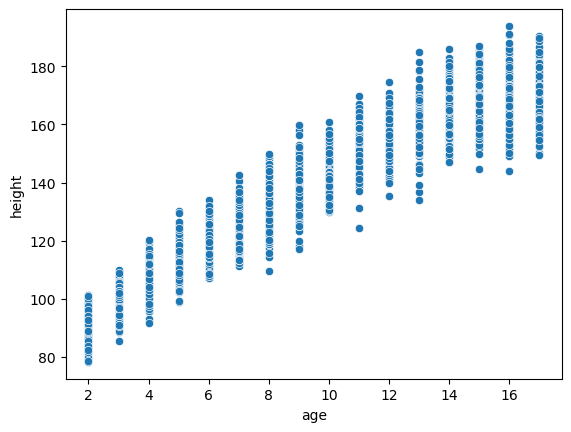

In [6]:
import seaborn as sns
import matplotlib.pyplot as plt

sns.scatterplot(x="age", y="height", data=height)
plt.show()

From the graph (and our intuition), height is increasing with age. We can also see from the graph that age is an integer, which may explain the large variation within an age group. Increases in age seem to be associated with increases in height, which indicates positive correlation. Let us formally test this: 

In [7]:
from scipy.stats import pearsonr

corr, p_value = pearsonr(height["height"], height["age"], alternative="greater")

print("Correlation:", corr)
print("p-value:", p_value)

Correlation: 0.9495448959826562
p-value: 0.0


Clearly, the correlation is very high ($\hat r= 0.95$), and the p-value is very low. We will reject the null, and conclude that the evidendece suggests that the correlation coefficient is positive. If we wanted to check if the correlation was negative ($H_A: r<0$), we would use *alternative = 'lesser'* and for a two-sided alternative hypothesis ($H_A: r\neq 0$), we would use *alternative = 'two-sided' (which is the default argument of the function). 

## Linear regression

We have concluded that height and age are positively correlated. We now want to **model** the relationship between height and age. We may want to predict the height of children, or we may want to find out how age and gender affect the height development of a child. We will start building a model for the latter, and then select the model that performs the best for the former afterwards. We start by fitting a simple linear regression using age only. 

In [8]:
# Load packages:
from statsmodels.formula.api import ols
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [9]:
ols_model_1 = ols(formula="height ~ age", data=height)
ols_result_1 = ols_model_1.fit()
print(ols_result_1.summary())
print("sigma2=", f"{ols_result_1.mse_resid:.1f}")

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.902
Model:                            OLS   Adj. R-squared:                  0.902
Method:                 Least Squares   F-statistic:                 2.356e+04
Date:                Tue, 14 Apr 2026   Prob (F-statistic):               0.00
Time:                        17:06:44   Log-Likelihood:                -9091.5
No. Observations:                2572   AIC:                         1.819e+04
Df Residuals:                    2570   BIC:                         1.820e+04
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
                 coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------
Intercept     85.3162      0.368    231.798      0.0

This is the standard printout table from a linear regression. There is a lot of information here.  The model we fitted here is height = $\beta_0+\beta_1$ age $+\epsilon$, where $\epsilon$ has expectation $0$ and variance $\sigma^2$. Note that the estimated variance of the residuals is not included in the OLS summary, but can be extracted using *ols.mse_resid*. We see that the estimated residual variance is $\hat\sigma^2 = 68.9$. The other parameters are estimated to $\hat\beta_0 = 85.3$ and $\hat\beta_1 = 5.5$. The interpretation of $\beta_1$ is the increase in height associated with a one-unit increase in age, or the average growth (in cm) per year. Let us plot the regression line: 

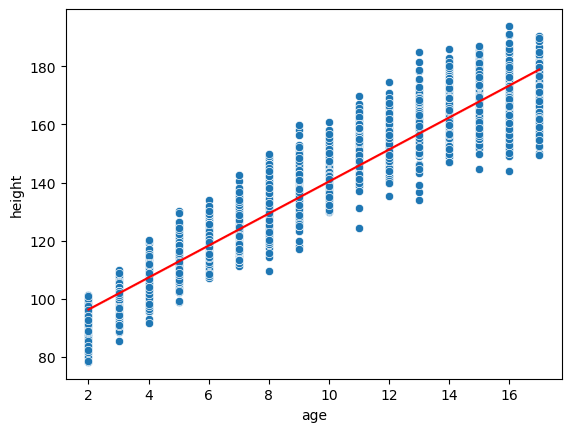

In [10]:
sns.scatterplot(x="age", y="height", data=height)
sns.lineplot(x="age", y=ols_result_1.fittedvalues, data=height, color="red")
plt.show()

Text(0.5, 1.0, 'Autocorrelation')

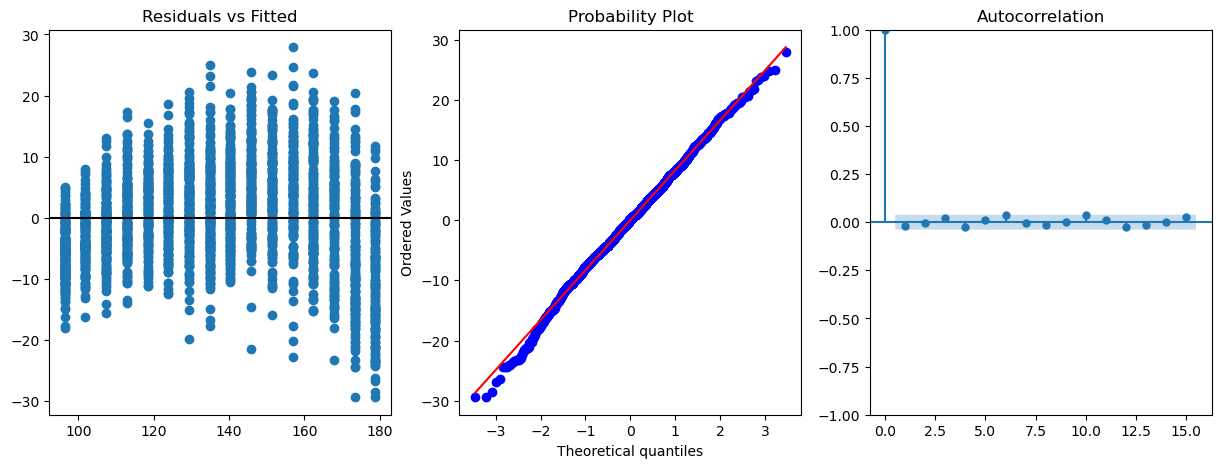

In [22]:
from statsmodels.graphics.tsaplots import plot_acf

fig, axes = plt.subplots(1, 3, figsize=(15, 5))
axes[0].scatter(ols_result_1.fittedvalues, ols_result_1.resid)
axes[0].axhline(0, lw=1.5, c="black")
axes[0].set_title("Residuals vs Fitted")

stats.probplot(ols_result_1.resid, plot=axes[1])

plot_acf(ols_result_1.resid, lags=15, ax=axes[2])
axes[2].set_title("Autocorrelation")

The residuals are distrubuted around zero, which indicates there is linerarity, and the assnmptions of the linear regression are fulfilled. The durbin-watson statistic is close to 2, which indicates that there is no autocorrelation in the residuals, which could also be shown in the residual autocorrelation plot. This means the residuals are independent, which is another assumption of the linear regression. The spred of the residuals seems to be constant across the fitted values, which indicates homoscedasticity, which is another assumption of the linear regression. The normal Q-Q plot shows that the residuals are approximately normally distributed, which is another assumption of the linear regression. Here only one variable is included in the model, meaning there is no multicollinearity.

#### Exercise:

1. Expand the model by adding *gender*. Plot the regression lines on top of the data.
2. Set up the modelling equation and identify the estimated coefficients.
3. Is this model better than the *age-only* model above in terms of AIC?
4. Set up a model equation that allows for male and female children to have different intercepts and different slopes as functions of age.
5. Fit this model. Does it improve AIC?
6. There is some curvature in the relationship between age and height. Add an age$^2$ term as covariate. Does this improve AIC?

In [ ]:
# Write your own code here:

ols_model_2 = ols(formula="height ~ age + C(gender)", data=height)
ols_result_2 = ols_model_2.fit()
print(ols_result_2.summary())
print("sigma2=", f"{ols_result_2.mse_resid:.1f}")

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.905
Model:                            OLS   Adj. R-squared:                  0.905
Method:                 Least Squares   F-statistic:                 1.225e+04
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:14:23   Log-Likelihood:                -9045.0
No. Observations:                2572   AIC:                         1.810e+04
Df Residuals:                    2569   BIC:                         1.811e+04
Df Model:                           2                                         
Covariance Type:            nonrobust                                         
                        coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------
Intercept            83.8128      0.39

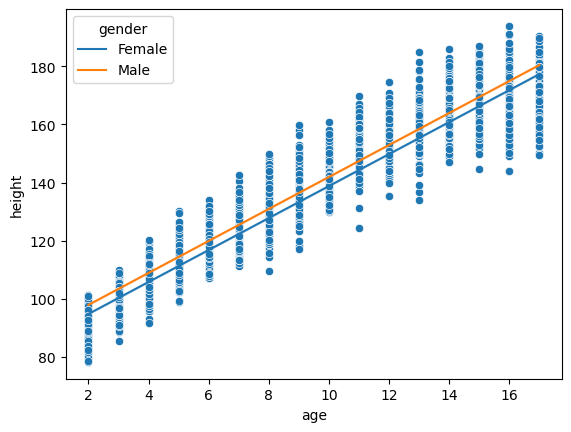

In [ ]:
sns.scatterplot(x="age", y="height", data=height)
sns.lineplot(
    x="age", y=ols_result_2.fittedvalues, hue="gender", data=height, color="red"
)
plt.show()

2. Model: height = $\beta_0 + \beta_1$ age + $\beta_2$ gender
Male height = 83.8 + 5.50 * age + 3.13
Female height = 83.8 + 5.50 * age 
3. This model has a lower AIC than the age-only model, so it is better in terms of AIC.
4. Modeling equation: height male = $\beta_0 + \beta_1$ age + $\beta_2$ gender + $\beta_3$ gender * age

In [ ]:
ols_model_3 = ols(formula="height ~ age*C(gender)", data=height)
ols_result_3 = ols_model_3.fit()
print(ols_result_3.summary())
print("sigma2=", f"{ols_result_3.mse_resid:.1f}")

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.908
Model:                            OLS   Adj. R-squared:                  0.908
Method:                 Least Squares   F-statistic:                     8479.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:49:18   Log-Likelihood:                -9001.3
No. Observations:                2572   AIC:                         1.801e+04
Df Residuals:                    2568   BIC:                         1.803e+04
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
                            coef    std err          t      P>|t|      [0.025      0.975]
-----------------------------------------------------------------------------------------
Intercept                86.79

5. The AIC is lower than the previous model, so this model is better in terms of AIC.


In [ ]:
height["age2"] = height["age"] ** 2
ols_model_4 = ols(formula="height ~ age + age*C(gender) + age2*C(gender)", data=height)
ols_result_4 = ols_model_4.fit()
print(ols_result_4.summary())
print("sigma2=", f"{ols_result_4.mse_resid:.1f}")

                            OLS Regression Results                            
Dep. Variable:                 height   R-squared:                       0.932
Model:                            OLS   Adj. R-squared:                  0.932
Method:                 Least Squares   F-statistic:                     7055.
Date:                Wed, 08 Apr 2026   Prob (F-statistic):               0.00
Time:                        11:51:53   Log-Likelihood:                -8613.2
No. Observations:                2572   AIC:                         1.724e+04
Df Residuals:                    2566   BIC:                         1.727e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
                             coef    std err          t      P>|t|      [0.025      0.975]
------------------------------------------------------------------------------------------
Intercept                 68

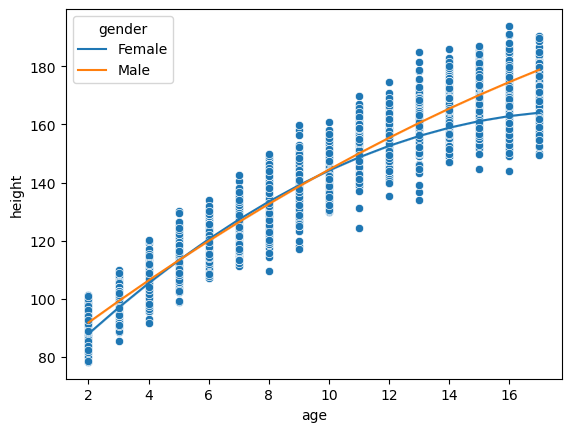

In [ ]:
sns.scatterplot(x="age", y="height", data=height)
sns.lineplot(x="age", y=ols_result_4.fittedvalues, hue="gender", data=height)
plt.show()

6. The AIC is lower than the previous model, so this model is better in terms of AIC.

    The new model for male height = $\beta_0 + \beta_1$ age + $\beta_2$ gender + $\beta_3$ gender * age + $\beta_4$ age^2 + $\beta_5$ age^2 * gender + $\epsilon$.

## Linear model for prediction

Now, say our main goal was not to describe gender differences in growth, but to predict a child's height based on their age and gender. We could then want to select the model that performs best in a prediction setting - that is, for unseen data. This is called out-of-sample performance. A good prediction model should have high predictive abilities on data it was not trained on. One way of doing this is to use a hold-out set (a test set), where you train the different candidate models on a portion of the data and evaluate them on another. This is the classical train-test split. 

Let's create a train-test split: 

In [ ]:
# Random permutation of the data:
indices = np.random.permutation(len(height))
# 80% for training, 20% for testing
split = int(0.8 * len(height))
# Extract the first ~80% indices for training and last 20% for testing:
train_idx, test_idx = indices[:split], indices[split:]

# Construct training and test data using the indices:
train = height.iloc[train_idx]  # <-- for fitting the models
test = height.iloc[test_idx]  # <-- for evaluating the models

In [ ]:
# The models:
formulas = [
    "height ~ age",
    "height ~ age + gender",
    "height ~ age*gender",
    "height ~ age*gender+age2*gender",
]
# Loop over model indices:
for i in range(len(formulas)):
    model = ols(formula=formulas[i], data=train)  # Set up model using training data
    fit = model.fit()  # Fit model
    pred = fit.predict(test)  # Predict on test data
    mse = np.sqrt(
        np.mean((pred - test["height"]) ** 2)
    )  # Calculate root mean square prediction error
    print(formulas[i], ":", f"{mse:.3f}")  # Print results

height ~ age : 8.506
height ~ age + gender : 8.286
height ~ age*gender : 8.094
height ~ age*gender+age2*gender : 6.961


We can see from the output that the model with the lowest prediction error is the most complex model, which was also the best model in terms of AIC, when we use the full dataset above. This procedure only consider the point prediction, which is the most common thing to do when doing model selection. 

We will now continue with "the best model", and say we want to make a nice graph showing how the model predicts unseen children, while also taking into account the uncertainty of such a prediction. For this, we need prediction intervals!

In [ ]:
# Using the most recent fit object:
pred_res = fit.get_prediction(test)
pred_df = pred_res.summary_frame(alpha=0.05)
print(pred_df)

           mean   mean_se  mean_ci_lower  mean_ci_upper  obs_ci_lower  \
0    156.036937  0.292501     155.463308     156.610567    142.524227   
1    113.119325  0.290702     112.549223     113.689428     99.606764   
2    144.102701  0.312586     143.489681     144.715720    130.588261   
3    138.666716  0.319098     138.040927     139.292505    125.151691   
4    162.979333  0.471475     162.054713     163.903952    149.447178   
..          ...       ...            ...            ...           ...   
510  127.176623  0.289628     126.608628     127.744617    113.664150   
511  162.979333  0.471475     162.054713     163.903952    149.447178   
512  138.666716  0.319098     138.040927     139.292505    125.151691   
513  120.425299  0.280140     119.875911     120.974686    106.913596   
514   99.286061  0.416295      98.469655     100.102466     85.760869   

     obs_ci_upper  
0      169.549648  
1      126.631886  
2      157.617140  
3      152.181741  
4      176.511487  
.. 

Using the code above, we have the mean prediction (the expected value/point prediction), the standard error of that prediction. The mean_ci_lower and mean_ci_upper constitutes the confidence interval for the expected value, while the obs_ci_lower and obs_ci_upper are 95% prediction interval. This gives the interval where new observations with 95% probability will fall into, according to the model. Lets plot it together with the test data.

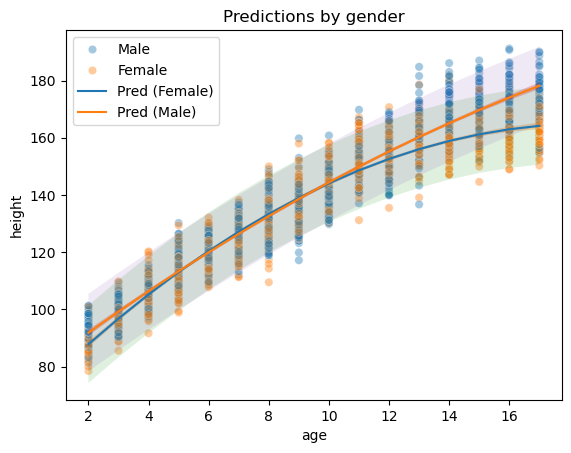

In [ ]:
# Merge test data and predictions:
import pandas as pd

plot_df = pd.concat([test.reset_index(), pred_df], axis=1)
plot_df = plot_df.sort_values("age")

plt.figure()

# Scatter (train data)
sns.scatterplot(data=train, x="age", y="height", hue="gender", alpha=0.4)

# Loop over genders for clean interval plotting
for g in plot_df["gender"].unique():
    df_g = plot_df[plot_df["gender"] == g].sort_values("age")

    # Prediction line
    sns.lineplot(data=df_g, x="age", y="mean", label=f"Pred ({g})")

    # Confidence interval
    plt.fill_between(
        df_g["age"], df_g["mean_ci_lower"], df_g["mean_ci_upper"], alpha=0.3
    )

    # Prediction interval
    plt.fill_between(
        df_g["age"], df_g["obs_ci_lower"], df_g["obs_ci_upper"], alpha=0.15
    )

plt.xlabel("age")
plt.ylabel("height")
plt.title("Predictions by gender")
plt.legend()
plt.show()

As you can see from the figure, the prediction interval is almost as wide as the spread of the data for the various ages. Note that this is for the test data, so the model has not been trained on this observations. The prediction intervals seem well tuned to the data. Note that around 5% of the test data observations is expected to lie outside the interval. 

Another relevant interval is the confidence interval (mean_ci_lower, mean_ci_upper). While the prediction interval is an interval that will cover new observations with 95% probability, the confidence interval is about the expected value of $Y$, often referred to as $\mu$. The prediction interval will always be wider than the corresponding confidence interval. Let us compare them for the female children's heights in another plot.

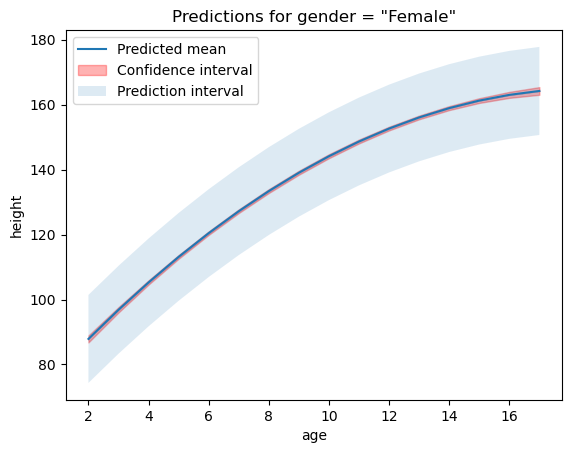

In [ ]:
df_f = plot_df[plot_df["gender"] == "Female"].sort_values("age")
plt.figure()

# Predicted mean line
sns.lineplot(data=df_f, x="age", y="mean", label="Predicted mean")

# Confidence interval
plt.fill_between(
    df_f["age"],
    df_f["mean_ci_lower"],
    df_f["mean_ci_upper"],
    color="red",
    alpha=0.3,
    label="Confidence interval",
)

# Prediction interval
plt.fill_between(
    df_f["age"],
    df_f["obs_ci_lower"],
    df_f["obs_ci_upper"],
    alpha=0.15,
    label="Prediction interval",
)

plt.xlabel("age")
plt.ylabel("height")
plt.title('Predictions for gender = "Female"')
plt.legend()
plt.show()

The dataset is quite large, so the uncertainty of the expected height at any given age is very low. 

# Cross validation
We used a simple train-test split above. An alternative to this is to use cross validation. This means that you divide the dataset into $k$ folds, and then, looping over the folds, you take out one fold at the time for testing, and use the other folds for training. The out-of-sample performence is then aggregated across the folds, making the decision of the "best model" more robust to the specific test set. 

In [ ]:
from sklearn.model_selection import KFold
import numpy as np
import pandas as pd
from statsmodels.formula.api import ols

# The models
formulas = [
    "height ~ age",
    "height ~ age + gender",
    "height ~ age*gender",
    "height ~ age*gender + age2*gender",
]

# Initiate 10-fold CV
kf = KFold(n_splits=10, shuffle=True, random_state=42)

# Store results
results = []

# Loop over models:
for formula in formulas:
    # Make a fresh copy for this model
    data = height.copy()
    data["Predicted"] = np.nan
    # Loop over the 10 folds:
    for train_index, test_index in kf.split(data):
        train_data = data.iloc[train_index]  # Training
        test_data = data.iloc[test_index]  # Testing

        # Fit model on training fold
        model = ols(formula=formula, data=train_data)
        trainfit = model.fit()

        # Predict on test fold
        data.iloc[test_index, data.columns.get_loc("Predicted")] = trainfit.predict(
            test_data
        )

    # Compute RMSE for this formula
    rmse = np.sqrt(np.mean((data["height"] - data["Predicted"]) ** 2))

    # Save result
    results.append({"formula": formula, "RMSE": rmse})

# Convert to DataFrame
results_df = pd.DataFrame(results)

print(results_df)

                             formula      RMSE
0                       height ~ age  8.303208
1              height ~ age + gender  8.157014
2                height ~ age*gender  8.023010
3  height ~ age*gender + age2*gender  6.904521


## Exercise
What does the output tell you?